In [1]:
!pip -q install "scipy==1.15.3" ninja click requests tqdm pillow gdown torchmetrics torch-fidelity pytorch-fid

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.0/62.0 kB 2.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 37.3/37.3 MB 41.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 183.4/183.4 kB 14.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 31.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 85.6/85.6 kB 8.2 MB/s eta 0:00:00


Generated image 1/10
Generated image 2/10
Generated image 3/10
Generated image 4/10
Generated image 5/10
Generated image 6/10
Generated image 7/10
Generated image 8/10
Generated image 9/10
Generated image 10/10


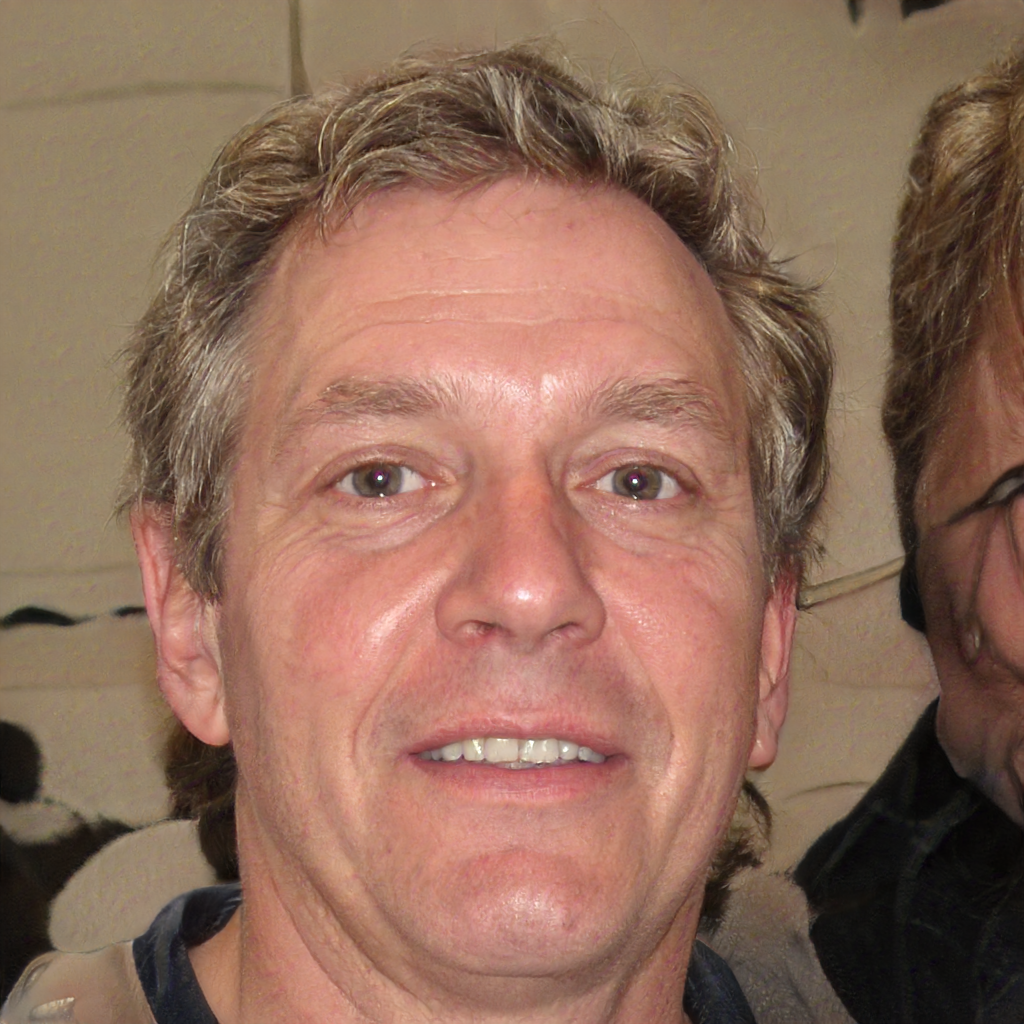

/usr/local/lib/python3.13/dist-packages/torchmetrics/utilities/prints.py:43: UserWarning: Metric `InceptionScore` will save all extracted features in buffer. For large datasets this may lead to large memory footprint.
  warnings.warn(*args, **kwargs)
Downloading: "https://github.com/toshas/torch-fidelity/releases/download/v0.2.0/weights-inception-2015-12-05-6726825d.pth" to /root/.cache/torch/hub/checkpoints/weights-inception-2015-12-05-6726825d.pth
100%|██████████| 91.2M/91.2M [00:00<00:00, 162MB/s]


Inception Score: 1.68 ± 0.07
Preparing CelebA dataset...


Downloading...
From (original): https://drive.google.com/uc?id=0B7EVK8r0v71pZjFTYXZWM3FlRnM
From (redirected): https://drive.usercontent.google.com/download?id=0B7EVK8r0v71pZjFTYXZWM3FlRnM&confirm=t&uuid=1cb99e8f-fca9-48c5-9c3b-0dca3408e0c3
To: /content/data/celeba/img_align_celeba.zip
100%|██████████| 1.44G/1.44G [00:18<00:00, 79.8MB/s]
Downloading...
From: https://drive.google.com/uc?id=0B7EVK8r0v71pblRyaVFSWGxPY0U
To: /content/data/celeba/list_attr_celeba.txt
100%|██████████| 26.7M/26.7M [00:00<00:00, 83.7MB/s]
Downloading...
From: https://drive.google.com/uc?id=1_ee_0u7vcNLOfNLegJRHmolfH5ICW-XS
To: /content/data/celeba/identity_CelebA.txt
100%|██████████| 3.42M/3.42M [00:00<00:00, 37.1MB/s]
Downloading...
From: https://drive.google.com/uc?id=0B7EVK8r0v71pbThiMVRxWXZ4dU0
To: /content/data/celeba/list_bbox_celeba.txt
100%|██████████| 6.08M/6.08M [00:00<00:00, 88.3MB/s]
Downloading...
From: https://drive.google.com/uc?id=0B7EVK8r0v71pd0FJY3Blby1HUTQ
To: /content/data/celeba/list_landm

Saved 10 real images
Downloading: "https://github.com/mseitzer/pytorch-fid/releases/download/fid_weights/pt_inception-2015-12-05-6726825d.pth" to /root/.cache/torch/hub/checkpoints/pt_inception-2015-12-05-6726825d.pth
FID:  9.410280493265757

Images saved in: /content/stylegan_ledohu1m


In [2]:
import os
import sys
import subprocess
import urllib.request
import tempfile

import torch
import torchvision.datasets as dsets
from torchvision import transforms
from torchvision.utils import save_image
from torchmetrics.image.inception import InceptionScore
from IPython.display import display, Image

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

if device.type != "cuda":
    raise RuntimeError("Enable T4 GPU in Colab and run this cell again.")

REPO = "/content/stylegan2-ada-pytorch"
REPO_URL = "https://github.com/NVlabs/stylegan2-ada-pytorch.git"
MODEL_URL = "https://nvlabs-fi-cdn.nvidia.com/stylegan2-ada-pytorch/pretrained/ffhq.pkl"
MODEL_PATH = "/content/ffhq.pkl"
NUM_IMAGES = 10

RUN_DIR = tempfile.mkdtemp(prefix="stylegan_", dir="/content")
GENERATED_DIR = os.path.join(RUN_DIR, "generated_images")
REAL_DIR = os.path.join(RUN_DIR, "real_images")

os.makedirs(GENERATED_DIR, exist_ok=True)
os.makedirs(REAL_DIR, exist_ok=True)

def clone_repo():
    if not os.path.exists(REPO):
        subprocess.run(
            ["git", "clone", REPO_URL, REPO],
            check=True
        )

    if REPO not in sys.path:
        sys.path.insert(0, REPO)

def download_model():
    if not os.path.exists(MODEL_PATH):
        print("Downloading pretrained model...")
        temporary_path = MODEL_PATH + ".part"
        urllib.request.urlretrieve(MODEL_URL, temporary_path)
        os.replace(temporary_path, MODEL_PATH)

def generate_images():
    import legacy
    from torch_utils.ops import upfirdn2d, bias_act

    upfirdn2d._init = lambda: False
    bias_act._init = lambda: False

    with open(MODEL_PATH, "rb") as file:
        generator = legacy.load_network_pkl(file)["G_ema"]

    generator = generator.eval().requires_grad_(False).to(device)
    images = []

    with torch.inference_mode():
        for i in range(NUM_IMAGES):
            z = torch.randn(1, generator.z_dim, device=device)
            label = torch.zeros(1, generator.c_dim, device=device)

            image = generator(
                z,
                label,
                truncation_psi=0.5,
                noise_mode="const"
            )

            image = ((image + 1) * 0.5).clamp(0, 1)
            image_path = os.path.join(
                GENERATED_DIR,
                f"fake_{i:03d}.png"
            )

            save_image(image, image_path)
            images.append(image.cpu())

            print(f"Generated image {i + 1}/{NUM_IMAGES}")

    del generator
    torch.cuda.empty_cache()

    display(
        Image(
            filename=os.path.join(GENERATED_DIR, "fake_000.png"),
            width=256
        )
    )

    return torch.cat(images)

def calculate_inception_score(images):
    metric = InceptionScore(splits=2, normalize=False).to(device)

    with torch.inference_mode():
        for batch in images.split(2):
            batch = (batch * 255).round().clamp(0, 255)
            batch = batch.to(device=device, dtype=torch.uint8)
            metric.update(batch)

        mean, std = metric.compute()

    print(
        f"Inception Score: "
        f"{mean.item():.2f} ± {std.item():.2f}"
    )

    del metric
    torch.cuda.empty_cache()

def prepare_real_images():
    print("Preparing CelebA dataset...")

    dataset = dsets.CelebA(
        root="/content/data",
        split="train",
        download=True,
        transform=transforms.Compose([
            transforms.Resize(512),
            transforms.CenterCrop(512),
            transforms.ToTensor()
        ])
    )

    indices = torch.randperm(
        len(dataset),
        generator=torch.Generator().manual_seed(42)
    )[:NUM_IMAGES]

    for i, index in enumerate(indices.tolist()):
        image, _ = dataset[index]
        image_path = os.path.join(
            REAL_DIR,
            f"real_{i:03d}.png"
        )
        save_image(image, image_path)

    print(f"Saved {NUM_IMAGES} real images")

def calculate_fid():
    result = subprocess.run(
        [
            sys.executable,
            "-m",
            "pytorch_fid",
            REAL_DIR,
            GENERATED_DIR,
            "--device",
            "cuda:0",
            "--batch-size",
            "2",
            "--dims",
            "64",
            "--num-workers",
            "0"
        ],
        capture_output=True,
        text=True
    )

    if result.stdout:
        print(result.stdout)

    if result.returncode != 0:
        raise RuntimeError(
            f"FID calculation failed:\n{result.stderr}"
        )

def main():
    clone_repo()
    download_model()
    images = generate_images()
    calculate_inception_score(images)
    del images
    prepare_real_images()
    calculate_fid()
    print(f"Images saved in: {RUN_DIR}")

main()